# E3 — Verificación visual de roturas sintéticas v2

Comprueba que los pares generados tienen forma de vasija y roturas coherentes.

**Qué ver:**
- ¿Las nubes tienen forma cilíndrica/hueca reconocible?
- ¿Las roturas son razonables (no vacías, no mínimas)?
- ¿Se aprecian los tres modos (plano, chip, cuña)?
- ¿Hay casos raros (nube dispersa, forma sin sentido)?

**Categorías esperadas:** mug · bowl · bottle · jar · can · cup · teacup

In [6]:
# ── CELDA 1: Montar Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.


In [7]:
# ── CELDA 2: Rutas y conteo ────────────────────────────────────
from pathlib import Path
import numpy as np

DRIVE      = '/content/drive/MyDrive'
RUTA_V2    = f'{DRIVE}/Datos_E2_E3/General/sintetico_roturas_v2'
RUTA_FB    = f'{DRIVE}/Datos_E2_E3/General/fantastic_breaks_procesado'  # ajusta si es distinta

dest = Path(RUTA_V2)
completos = sorted(dest.glob('*_completo.npy'))
print(f'Pares en sintetico_roturas_v2 : {len(completos)}')
print(f'  ShapeNet  : {sum(1 for f in completos if f.stem.startswith("shapenet"))}')
print(f'  Objaverse : {sum(1 for f in completos if f.stem.startswith("objaverse"))}')

fb = Path(RUTA_FB)
if fb.exists():
    fb_completos = sorted(fb.glob('*_completo.npy'))
    print(f'Pares Fantastic Breaks         : {len(fb_completos)}')
else:
    print('Fantastic Breaks: ruta no encontrada (ajusta RUTA_FB)')
    fb_completos = []

Pares en sintetico_roturas_v2 : 2299
  ShapeNet  : 2102
  Objaverse : 197
Fantastic Breaks: ruta no encontrada (ajusta RUTA_FB)


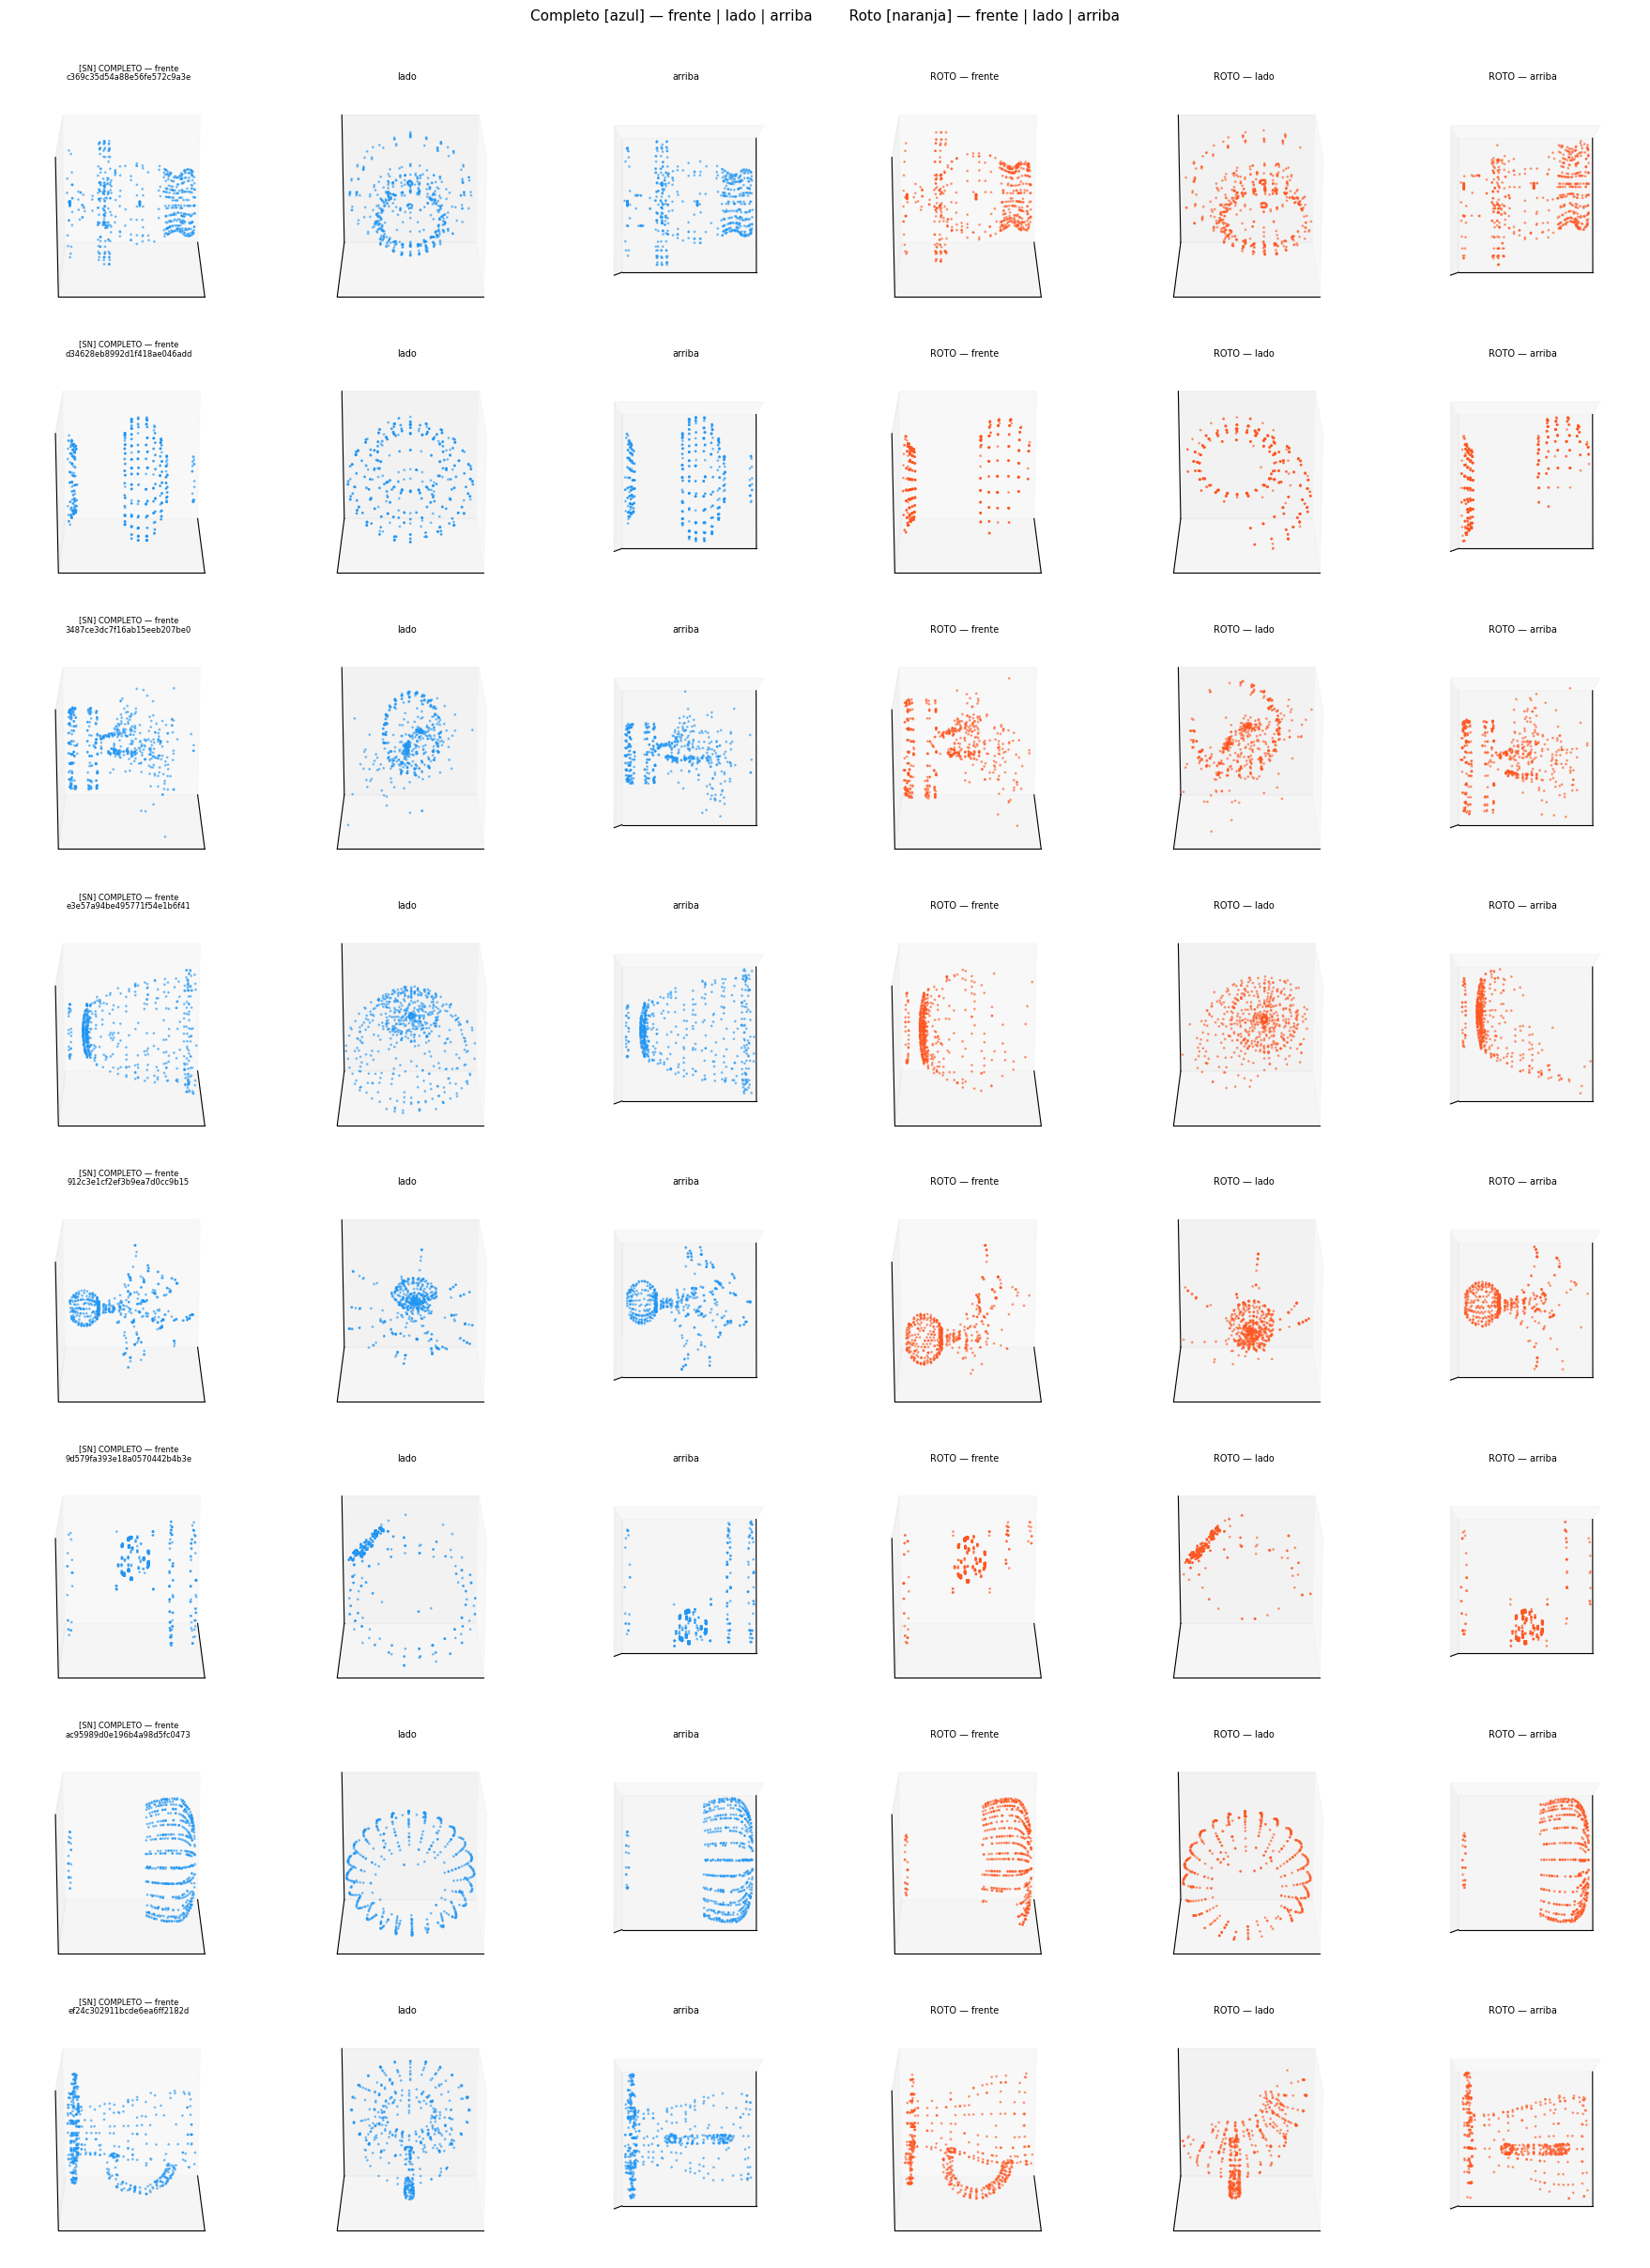

Guardado: verificacion_3vistas.png


In [8]:
# ── CELDA 3: 3 vistas por nube (frente / lado / arriba) ────────
# Cada fila = 1 ejemplo. Columnas: completo×3 vistas | roto×3 vistas
# Cambia SEMILLA para ver otros ejemplos.

import matplotlib.pyplot as plt
import numpy as np

N_MOSTRAR  = 8
SEMILLA    = 7
PUNTOS_VIZ = 600

VISTAS = [
    (20,  0,  'frente'),
    (20, 90,  'lado'),
    (88,  0,  'arriba'),
]

rng    = np.random.default_rng(SEMILLA)
muestra = rng.choice(len(completos), min(N_MOSTRAR, len(completos)), replace=False)

fig, axes = plt.subplots(
    N_MOSTRAR, 6,
    figsize=(18, N_MOSTRAR * 3),
    subplot_kw={'projection': '3d'}
)
fig.suptitle(
    'Completo [azul] — frente | lado | arriba        Roto [naranja] — frente | lado | arriba',
    fontsize=11, y=1.005
)

def scatter3(ax, pts, color, elev, azim):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=color, s=1, alpha=0.5)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_box_aspect([1, 1, 1])

for fila, idx in enumerate(muestra):
    c = np.load(completos[idx])
    r = np.load(dest / completos[idx].name.replace('_completo', '_roto'))
    nombre = completos[idx].stem.replace('_completo', '')
    fuente = 'SN' if nombre.startswith('shapenet') else 'OBJ'

    ic = rng.choice(len(c), min(PUNTOS_VIZ, len(c)), replace=False)
    ir = rng.choice(len(r), min(PUNTOS_VIZ, len(r)), replace=False)

    for v, (elev, azim, vista_nombre) in enumerate(VISTAS):
        # completo — columnas 0,1,2
        ax_c = axes[fila][v]
        scatter3(ax_c, c[ic], '#2196F3', elev, azim)
        if v == 0:
            ax_c.set_title(f'[{fuente}] COMPLETO — {vista_nombre}\n{nombre[9:35]}', fontsize=6)
        else:
            ax_c.set_title(vista_nombre, fontsize=7)

        # roto — columnas 3,4,5
        ax_r = axes[fila][v + 3]
        scatter3(ax_r, r[ir], '#FF5722', elev, azim)
        ax_r.set_title(f'ROTO — {vista_nombre}', fontsize=7)

plt.tight_layout()
plt.savefig('verificacion_3vistas.png', dpi=90, bbox_inches='tight')
plt.show()
print('Guardado: verificacion_3vistas.png')

In [9]:
# ── CELDA 4: Visualizar pares de Fantastic Breaks ─────────────
# Para comparar: así son las roturas REALES vs las sintéticas.

if not fb_completos:
    print('Sin pares de Fantastic Breaks — ajusta RUTA_FB en Celda 2')
else:
    N_FB = min(8, len(fb_completos))
    muestra_fb = rng.choice(len(fb_completos), N_FB, replace=False)

    fig2, axes2 = plt.subplots(N_FB, 2, figsize=(10, N_FB * 3),
                               subplot_kw={'projection': '3d'})
    fig2.suptitle('Fantastic Breaks — REALES — completo (azul) | roto (rojo)', fontsize=13, y=1.01)

    for fila, idx in enumerate(muestra_fb):
        ruta_c = fb_completos[idx]
        ruta_r = fb / ruta_c.name.replace('_completo', '_roto')
        if not ruta_r.exists():
            continue

        c = np.load(ruta_c)
        r = np.load(ruta_r)
        ic = rng.choice(len(c), min(PUNTOS_VIZ, len(c)), replace=False)
        ir = rng.choice(len(r), min(PUNTOS_VIZ, len(r)), replace=False)
        pct_roto = round((1 - len(r) / len(c)) * 100) if len(c) > 0 else 0

        for col, (pts, color, titulo) in enumerate([
            (c[ic], '#1565C0', f'FB COMPLETO\n{ruta_c.stem[:30]}'),
            (r[ir], '#B71C1C', f'FB ROTO ({pct_roto}% menos)'),
        ]):
            ax = axes2[fila][col]
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                       c=color, s=1, alpha=0.6)
            ax.set_title(titulo, fontsize=7, pad=2)
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
            ax.set_box_aspect([1, 1, 1])

    plt.tight_layout()
    plt.savefig('verificacion_fantastic_breaks.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Guardado: verificacion_fantastic_breaks.png')

Sin pares de Fantastic Breaks — ajusta RUTA_FB en Celda 2


Escaneados: 500 pares
  Sin outliers (0%)    : 318
  Outliers leves (<5%) : 120
  Outliers medios (5-15%): 62
  Outliers graves (≥15%): 0

Top 5 peores:
  14.6% outliers — shapenet_9d579fa393e18a0570442b4b3eac5c43_completo.npy
  10.9% outliers — shapenet_e9bd4ee553eb35c1d5ccc40b510e4bd_completo.npy
  10.8% outliers — shapenet_91e4df396135fc1e368b14e48c164a6e_completo.npy
  10.6% outliers — shapenet_942887c8d668501681faebbdea6bd9be_completo.npy
  10.5% outliers — shapenet_3bf6160225cd15453a762233fffc49ea_completo.npy


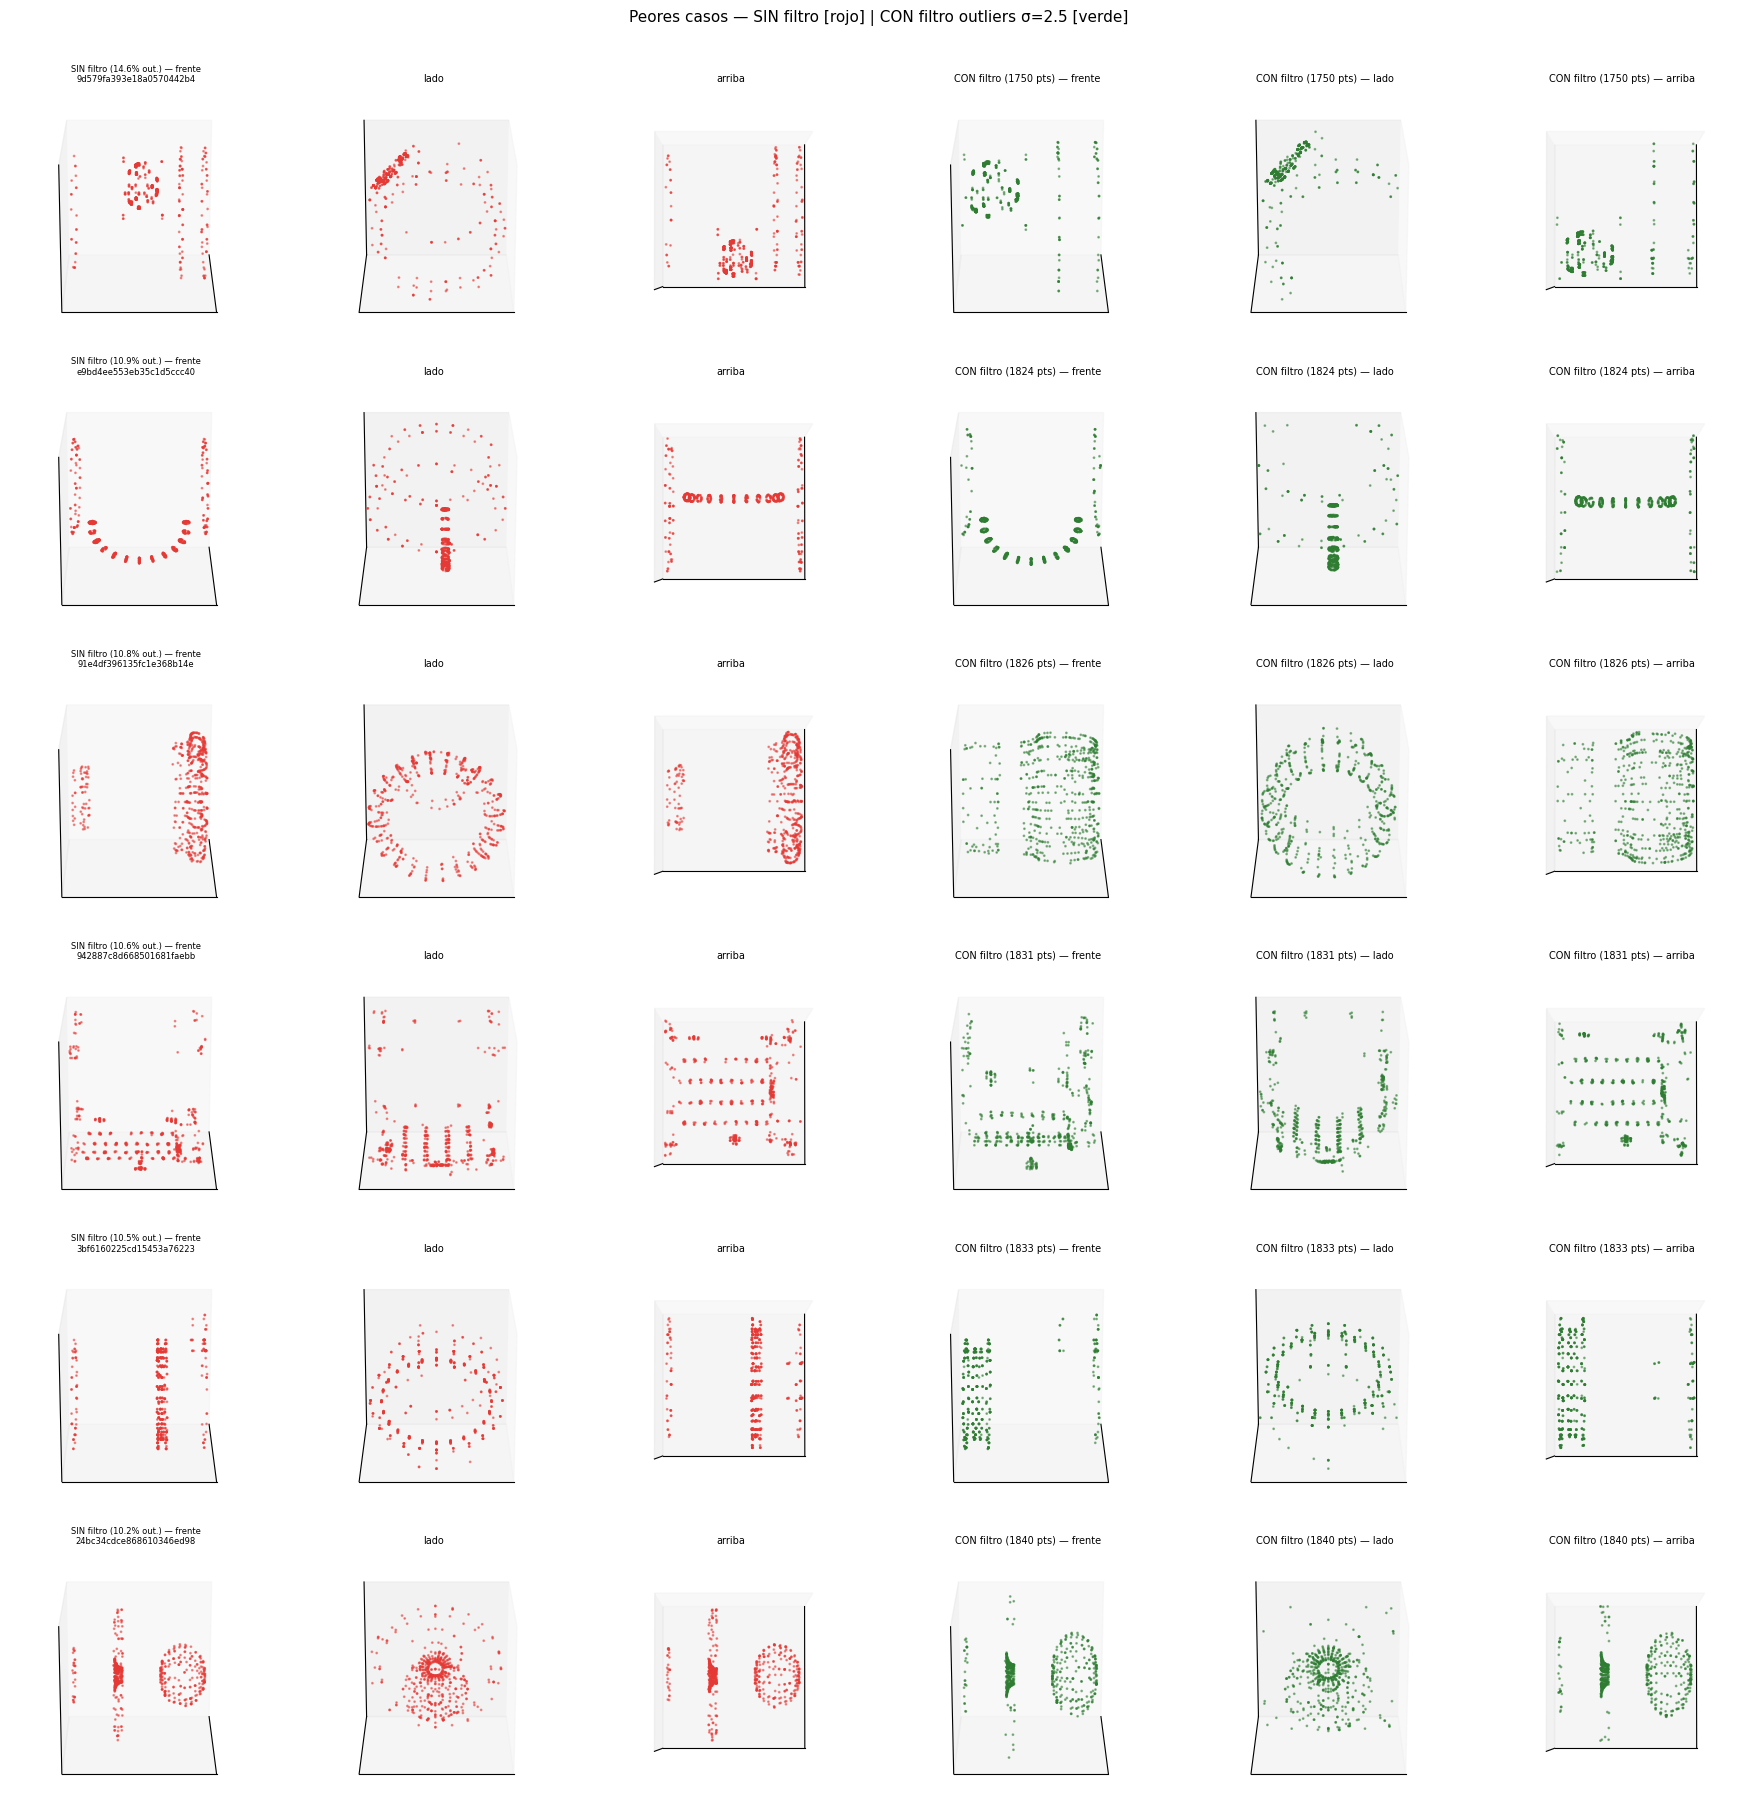

Guardado: peores_casos_filtro.png


In [10]:
# ── CELDA 5: Detección de pares problemáticos ─────────────────
# Escanea N_SCAN pares aleatorios y mide cuántos puntos serían
# eliminados por el filtro de outliers (sigma=2.5).
# Muestra los 8 peores casos con 3 vistas: original vs filtrado.

import matplotlib.pyplot as plt
import numpy as np

N_SCAN = 500   # pares a escanear (aumenta para más cobertura)
SIGMA  = 2.5   # umbral del filtro
SEMILLA_SCAN = 99

def quitar_outliers(pts, sigma=2.5):
    mean = pts.mean(axis=0)
    std  = pts.std(axis=0).clip(min=1e-6)
    mask = np.all(np.abs(pts - mean) <= sigma * std, axis=1)
    return pts[mask], mask

rng2   = np.random.default_rng(SEMILLA_SCAN)
ids    = rng2.choice(len(completos), min(N_SCAN, len(completos)), replace=False)

resultados = []
for idx in ids:
    c = np.load(completos[idx])
    _, mask = quitar_outliers(c, SIGMA)
    pct_outlier = 100 * (1 - mask.sum() / len(c))
    resultados.append((pct_outlier, idx))

resultados.sort(reverse=True)
print(f'Escaneados: {N_SCAN} pares')
print(f'  Sin outliers (0%)    : {sum(1 for p,_ in resultados if p == 0)}')
print(f'  Outliers leves (<5%) : {sum(1 for p,_ in resultados if 0 < p < 5)}')
print(f'  Outliers medios (5-15%): {sum(1 for p,_ in resultados if 5 <= p < 15)}')
print(f'  Outliers graves (≥15%): {sum(1 for p,_ in resultados if p >= 15)}')
print(f'\nTop 5 peores:')
for pct, idx in resultados[:5]:
    print(f'  {pct:.1f}% outliers — {completos[idx].name}')

# ── visualizar los 6 peores: antes vs después del filtro ──────
N_PEORES = 6
VISTAS2  = [(20, 0, 'frente'), (20, 90, 'lado'), (88, 0, 'arriba')]
rng3 = np.random.default_rng(0)

fig, axes = plt.subplots(
    N_PEORES, 6,
    figsize=(18, N_PEORES * 3),
    subplot_kw={'projection': '3d'}
)
fig.suptitle(
    'Peores casos — SIN filtro [rojo] | CON filtro outliers σ=2.5 [verde]',
    fontsize=11, y=1.005
)

for fila, (pct, idx) in enumerate(resultados[:N_PEORES]):
    c = np.load(completos[idx])
    c_filt, _ = quitar_outliers(c, SIGMA)
    nombre = completos[idx].stem.replace('_completo', '')

    # submuestreo para visualización
    n = min(600, len(c))
    ic     = rng3.choice(len(c),      n, replace=False)
    ic_f   = rng3.choice(len(c_filt), min(n, len(c_filt)), replace=False)

    for v, (elev, azim, vname) in enumerate(VISTAS2):
        # sin filtro
        ax1 = axes[fila][v]
        ax1.scatter(c[ic, 0], c[ic, 1], c[ic, 2], c='#E53935', s=1, alpha=0.5)
        ax1.view_init(elev=elev, azim=azim)
        ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])
        ax1.set_box_aspect([1, 1, 1])
        if v == 0:
            ax1.set_title(f'SIN filtro ({pct:.1f}% out.) — {vname}\n{nombre[9:32]}', fontsize=6)
        else:
            ax1.set_title(vname, fontsize=7)

        # con filtro
        ax2 = axes[fila][v + 3]
        ax2.scatter(c_filt[ic_f, 0], c_filt[ic_f, 1], c_filt[ic_f, 2],
                    c='#2E7D32', s=1, alpha=0.5)
        ax2.view_init(elev=elev, azim=azim)
        ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
        ax2.set_box_aspect([1, 1, 1])
        ax2.set_title(f'CON filtro ({len(c_filt)} pts) — {vname}', fontsize=7)

plt.tight_layout()
plt.savefig('peores_casos_filtro.png', dpi=90, bbox_inches='tight')
plt.show()
print('Guardado: peores_casos_filtro.png')

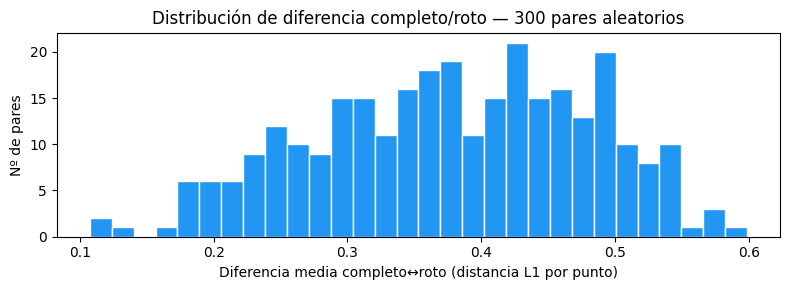

Diferencia media: 0.3771
Desv. estándar  : 0.1010
Mín / Máx       : 0.1075 / 0.5988

Si la distribución está centrada y no hay picos en 0 ni en el máximo,
las roturas son variadas y razonables.


In [11]:
# ── CELDA 5: Estadísticas de las roturas ──────────────────────
# Cuántos puntos quedan en los roturas → distribución del % eliminado.

import matplotlib.pyplot as plt
import numpy as np

N_MUESTRA_STATS = 300
muestra_stats = np.random.default_rng(0).choice(len(completos),
                    min(N_MUESTRA_STATS, len(completos)), replace=False)

fracciones = []
for idx in muestra_stats:
    c = np.load(completos[idx])
    r = np.load(dest / completos[idx].name.replace('_completo', '_roto'))
    # ambos tienen 2048 puntos (por submuestreo), así que la fracción
    # real de rotura la inferimos del número de puntos ANTES de submuestrear.
    # Como ambos son 2048 exactos, la medida directa no aplica.
    # En su lugar verificamos que los puntos son distintos.
    fracciones.append(np.mean(np.abs(c - r)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(fracciones, bins=30, color='#2196F3', edgecolor='white')
ax.set_xlabel('Diferencia media completo↔roto (distancia L1 por punto)')
ax.set_ylabel('Nº de pares')
ax.set_title(f'Distribución de diferencia completo/roto — {N_MUESTRA_STATS} pares aleatorios')
plt.tight_layout()
plt.savefig('stats_roturas.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Diferencia media: {np.mean(fracciones):.4f}')
print(f'Desv. estándar  : {np.std(fracciones):.4f}')
print(f'Mín / Máx       : {np.min(fracciones):.4f} / {np.max(fracciones):.4f}')
print('\nSi la distribución está centrada y no hay picos en 0 ni en el máximo,')
print('las roturas son variadas y razonables.')